In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\Python Programing\Python Practice\Demos\House price prediiction\Datasets\Ready for analysis.csv")

# Univariant analysis

In [3]:
df.dtypes

Price (in rupees)      float64
location                object
Transaction             object
Furnishing              object
facing                  object
Bathroom                 int64
Balcony                float64
Ownership               object
Sqrt_Area              float64
current_floor          float64
total_floors           float64
Amount_numeric         float64
price_log              float64
Sqrt_Area_transform    float64
overlook_garden          int64
overlook_mainroad        int64
overlook_pool            int64
dtype: object

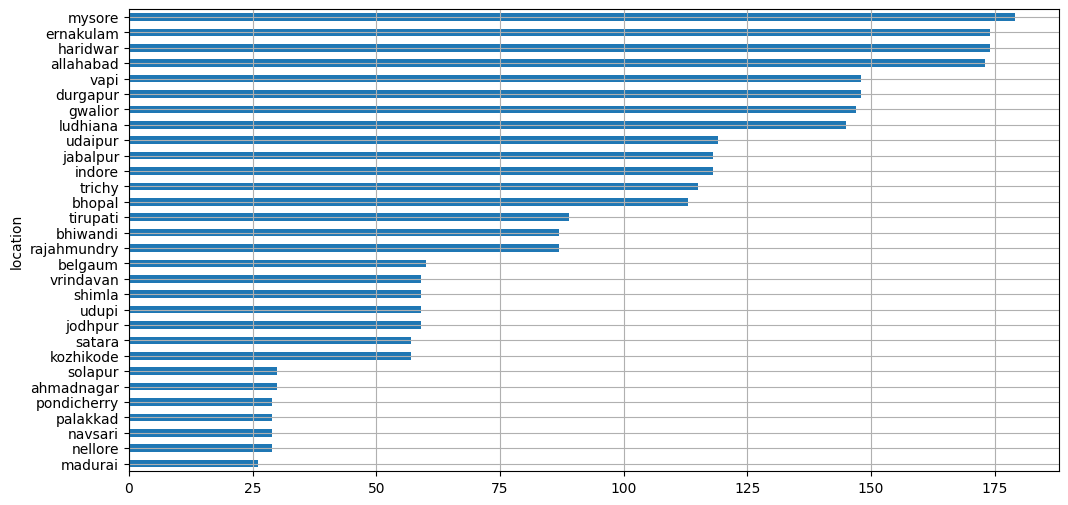

In [4]:
c_loc = df['location'].value_counts(ascending=True).head(30)
plt.figure(figsize=(12,6))
c_loc.plot(kind='barh')
plt.grid(True)

<Axes: ylabel='Transaction'>

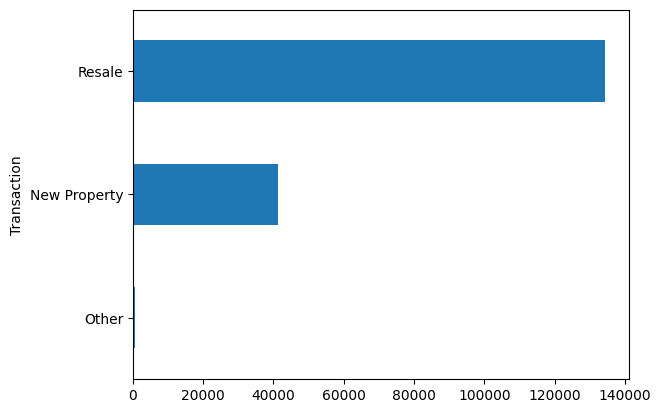

In [5]:
df['Transaction'].value_counts(ascending=True).plot(kind='barh')

In [6]:
def plot(col):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    sns.boxplot(x=df[col], ax=ax[1], color='skyblue')
    ax[0].set_title(f'Distribution of {col}')
    ax[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()
    return df[col].skew()

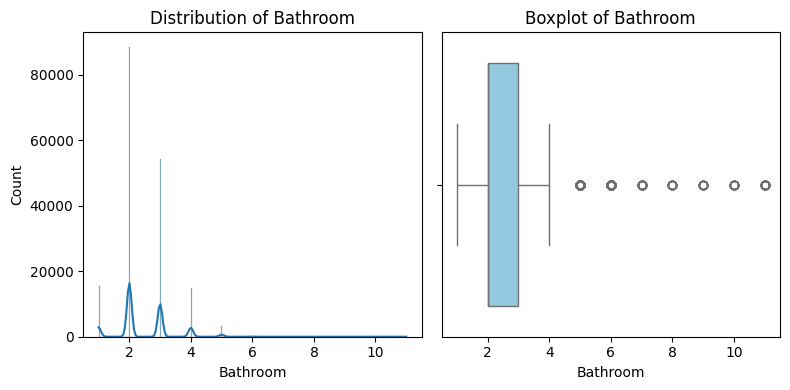

np.float64(0.9196848595671155)

In [7]:
plot('Bathroom')

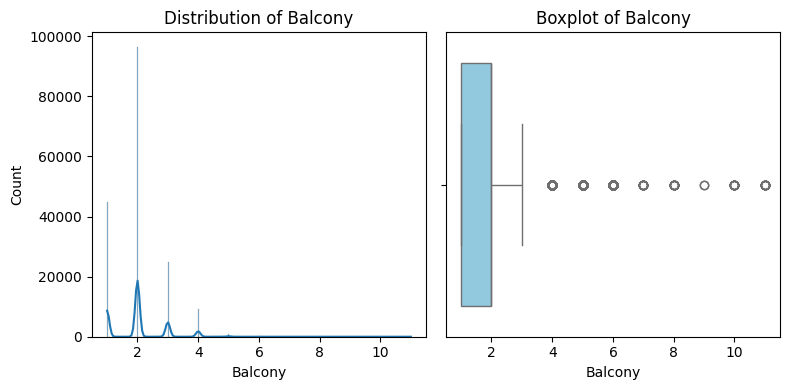

np.float64(1.054786462956205)

In [8]:
plot('Balcony')

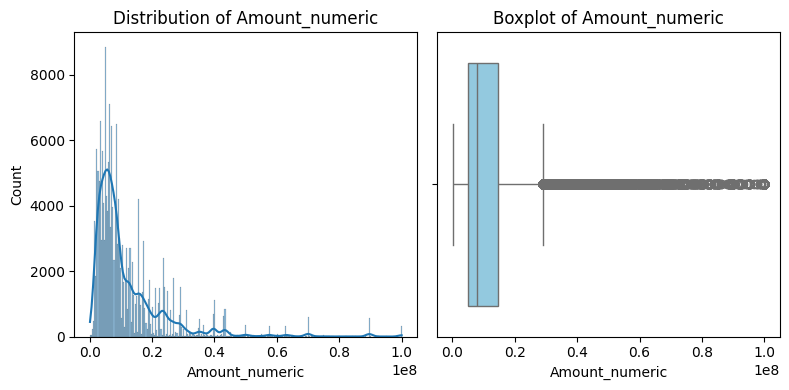

np.float64(3.1992289055671908)

In [9]:
plot('Amount_numeric')

In [10]:
(df['Amount_numeric']<0).sum()

np.int64(0)

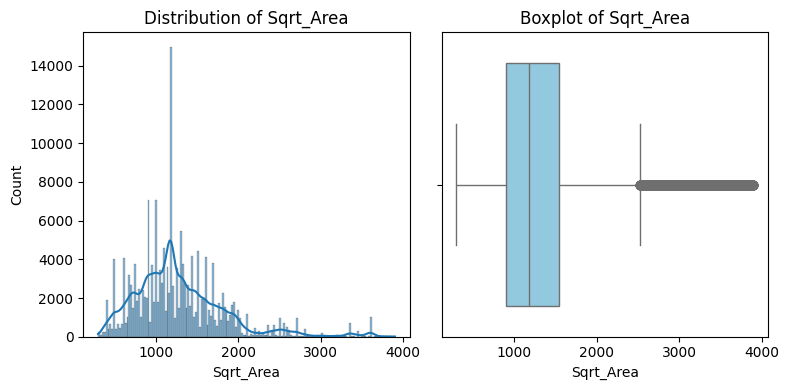

np.float64(1.3507957412237968)

In [11]:
plot('Sqrt_Area')

In [12]:
(df['Sqrt_Area']<0).sum()

np.int64(0)

# Conclusion: `Univariant Analysis` 
- **Target Column:** `Amount Numeric` is highly positively skewed and contain also with outliers.
- **Feature Column** `Sqrt_Area` is positively skewed and contain also with outliers.
- **Feature Column** `Balcony` is positively skewed but it's most likely as categorical column so safe to used.
- **Feature Column** `Bathroom` is positively skewed but it's most likely as categorical column so safe to used.

# Bivariant/Multivariant analysis 

### Numeric Vs Numeric

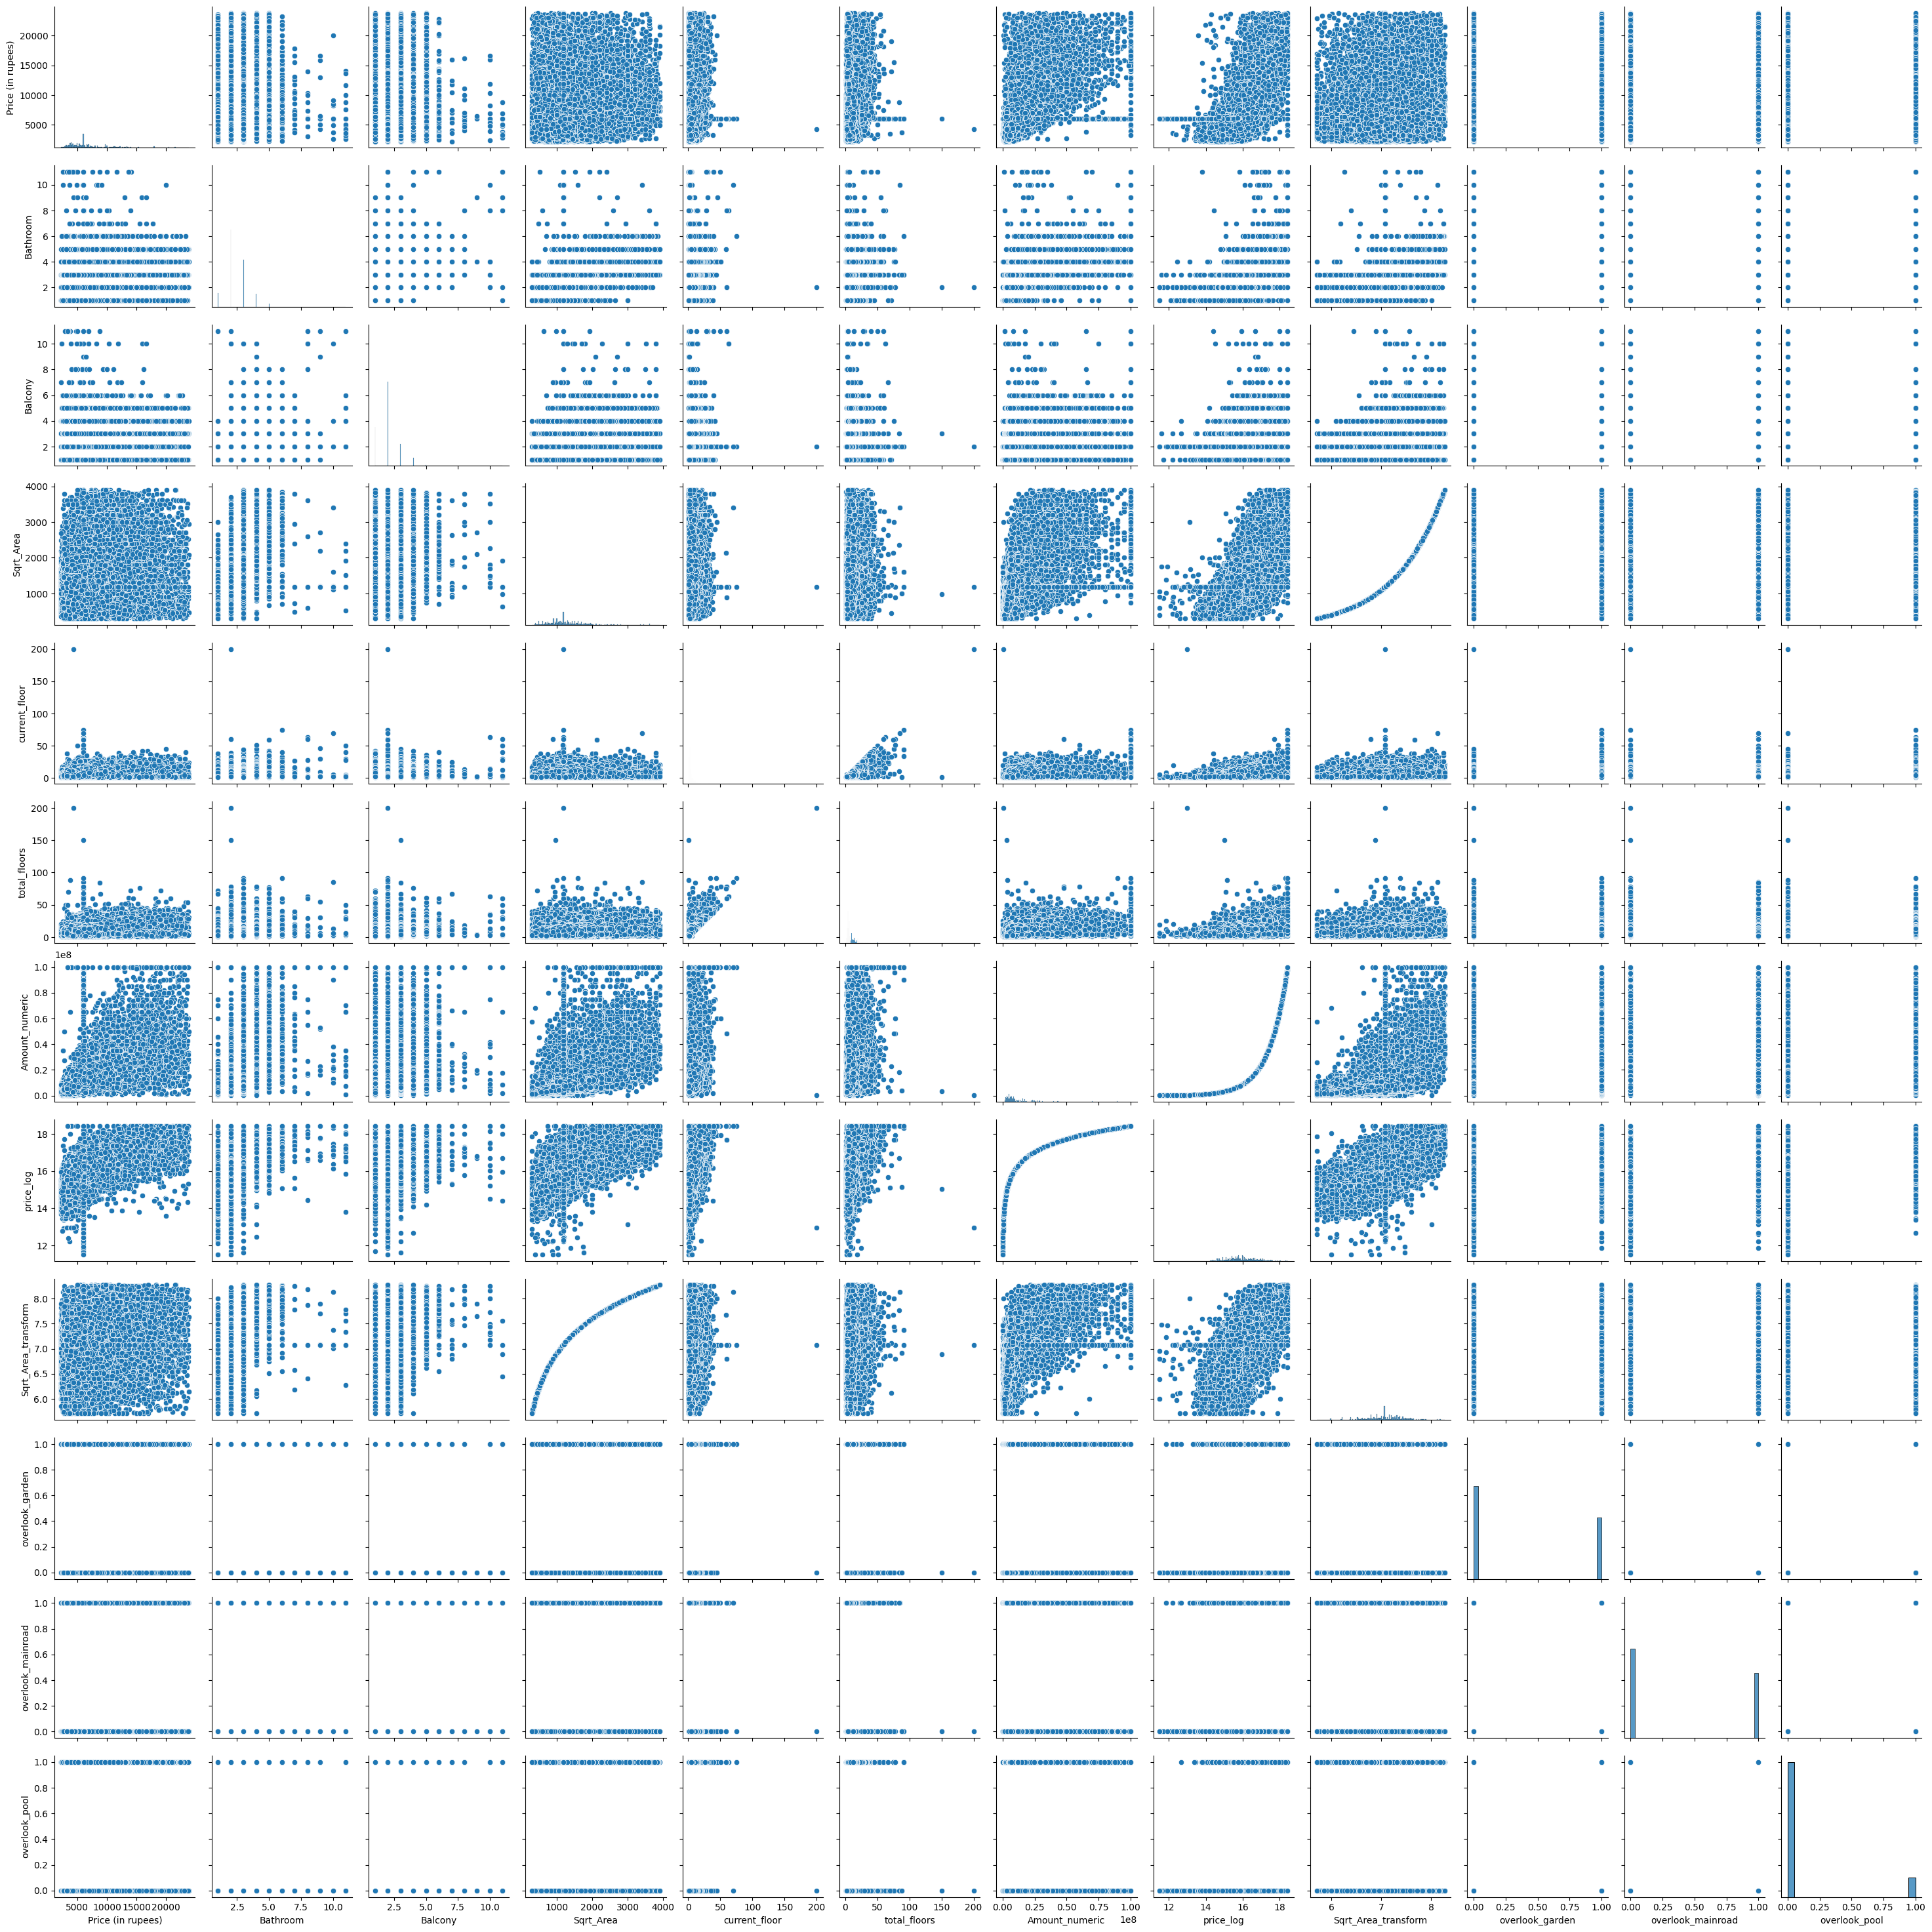

In [13]:
sns.pairplot(df)

In [14]:
num = df.select_dtypes(include='number')
corr = num.corr()

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0.5, 0, 'Price (in rupees)'),
  Text(1.5, 0, 'Bathroom'),
  Text(2.5, 0, 'Balcony'),
  Text(3.5, 0, 'Sqrt_Area'),
  Text(4.5, 0, 'current_floor'),
  Text(5.5, 0, 'total_floors'),
  Text(6.5, 0, 'Amount_numeric'),
  Text(7.5, 0, 'price_log'),
  Text(8.5, 0, 'Sqrt_Area_transform'),
  Text(9.5, 0, 'overlook_garden'),
  Text(10.5, 0, 'overlook_mainroad'),
  Text(11.5, 0, 'overlook_pool')])

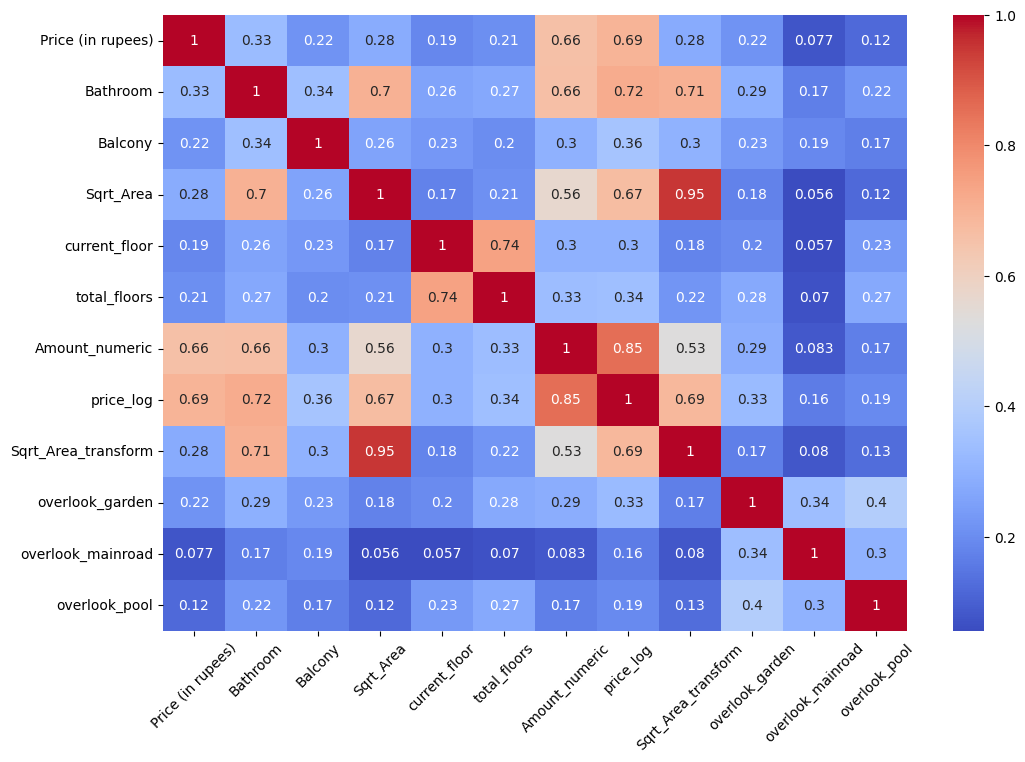

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.xticks(rotation=45)

### Categorical VS Numeric

In [16]:
print("Mean: ",df.groupby('location')['price_log'].mean())
print("\nMedian: ",df.groupby('location')['price_log'].median())
print("\nDescription: ",df.groupby('location')['price_log'].describe())

Mean:  location
agra             15.310537
ahmadnagar       15.049185
ahmedabad        15.886740
allahabad        15.672693
aurangabad       15.055574
                   ...    
varanasi         15.496797
vijayawada       15.400405
visakhapatnam    15.594264
vrindavan        15.036976
zirakpur         15.637917
Name: price_log, Length: 81, dtype: float64

Median:  location
agra             15.297115
ahmadnagar       14.930518
ahmedabad        15.761421
allahabad        15.687313
aurangabad       15.068274
                   ...    
varanasi         15.547166
vijayawada       15.319588
visakhapatnam    15.520259
vrindavan        14.914123
zirakpur         15.656060
Name: price_log, Length: 81, dtype: float64

Description:                   count       mean       std        min        25%        50%  \
location                                                                       
agra             434.0  15.310537  0.597726  12.468441  14.978662  15.297115   
ahmadnagar        30.0  15.0

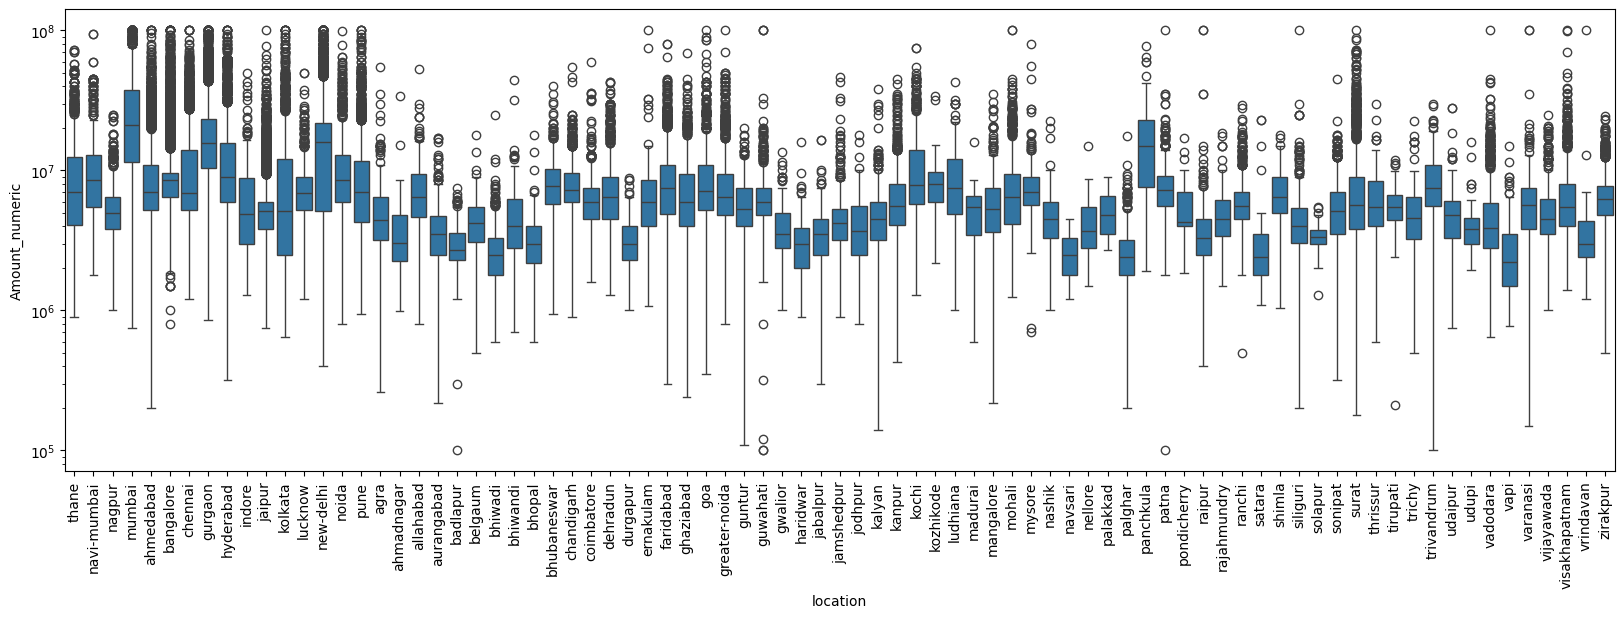

In [17]:
plt.figure(figsize=(20,6))
sns.boxplot(x='location', y='Amount_numeric', data=df)
plt.yscale('log')
plt.xticks(rotation=90)
plt.show()

In [18]:
print("Mean: ",df.groupby('Transaction')['price_log'].mean())
print("\nMedian: ",df.groupby('Transaction')['price_log'].median())
print("\nDescription: ",df.groupby('Transaction')['price_log'].describe())

Mean:  Transaction
New Property    16.117215
Other           15.344091
Resale          15.870166
Name: price_log, dtype: float64

Median:  Transaction
New Property    16.045525
Other           15.319588
Resale          15.830414
Name: price_log, dtype: float64

Description:                   count       mean       std        min        25%        50%  \
Transaction                                                                    
New Property   41309.0  16.117215  0.857413  11.608245  15.511126  16.045525   
Other            703.0  15.344091  0.216895  14.285515  15.319588  15.319588   
Resale        134416.0  15.870166  0.799296  11.512935  15.319588  15.830414   

                    75%        max  
Transaction                         
New Property  16.618871  18.420681  
Other         15.319588  17.296751  
Resale        16.425580  18.420681  


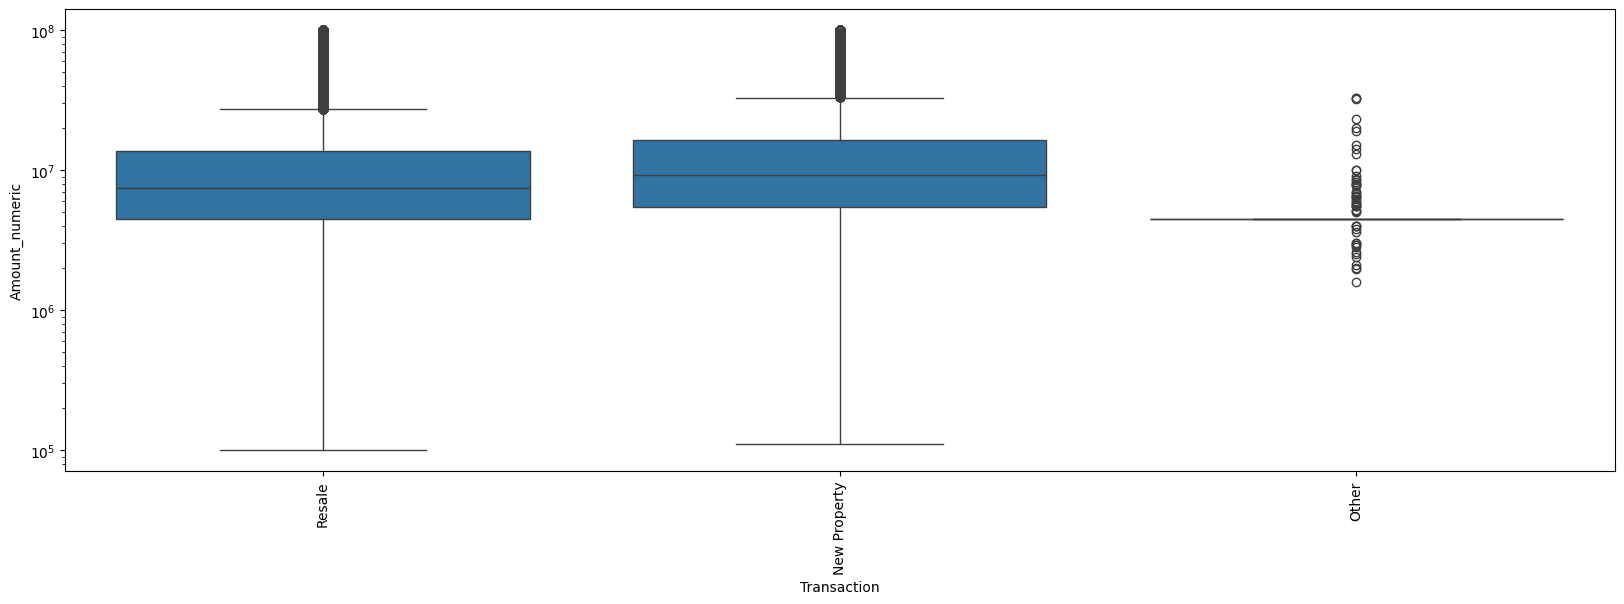

In [19]:
plt.figure(figsize=(20,6))
sns.boxplot(x='Transaction', y='Amount_numeric', data=df)
plt.yscale('log')
plt.xticks(rotation=90)
plt.show()

In [20]:
def detail(col):
    print("Mean: ",df.groupby(col)['price_log'].mean())
    print("\nMedian: ",df.groupby(col)['price_log'].median())
    print("\nDescription: ",df.groupby(col)['price_log'].describe())

In [21]:
detail('Furnishing')

Mean:  Furnishing
Furnished         15.832172
Semi-Furnished    16.033617
Unfurnished       15.831954
Unknown           15.786702
Name: price_log, dtype: float64

Median:  Furnishing
Furnished         15.830414
Semi-Furnished    15.990262
Unfurnished       15.761421
Unknown           15.640060
Name: price_log, dtype: float64

Description:                    count       mean       std        min        25%        50%  \
Furnishing                                                                      
Furnished       19361.0  15.832172  0.835567  11.608245  15.250595  15.830414   
Semi-Furnished  82484.0  16.033617  0.804589  11.512935  15.469922  15.990262   
Unfurnished     73236.0  15.831954  0.819122  11.512935  15.319588  15.761421   
Unknown          1347.0  15.786702  0.663211  12.765691  15.464169  15.640060   

                      75%        max  
Furnishing                            
Furnished       16.395727  18.420681  
Semi-Furnished  16.642824  18.420681  
Unfurnished    

In [22]:
detail('facing')

Mean:  facing
East            16.046092
North           16.031190
North - East    16.278628
North - West    16.172126
South           16.264142
South - East    15.699004
South -West     15.607807
Unknown         15.648529
West            16.014227
Name: price_log, dtype: float64

Median:  facing
East            15.955577
North           15.931766
North - East    16.308716
North - West    16.588099
South           16.425580
South - East    15.694947
South -West     15.869634
Unknown         15.656060
West            15.830414
Name: price_log, dtype: float64

Description:                  count       mean       std        min        25%        50%  \
facing                                                                        
East          52158.0  16.046092  0.786731  11.608245  15.520259  15.955577   
North         15032.0  16.031190  0.819633  11.849405  15.520259  15.931766   
North - East  23325.0  16.278628  0.926558  11.695255  15.687313  16.308716   
North - West   3800.0  16.1

In [23]:
detail('Ownership')

Mean:  Ownership
Co-operative Society    15.660499
Freehold                15.925013
Leasehold               16.088847
Power Of Attorney       16.131744
Name: price_log, dtype: float64

Median:  Ownership
Co-operative Society    15.520259
Freehold                15.869634
Leasehold               16.056220
Power Of Attorney       16.606676
Name: price_log, dtype: float64

Description:                           count       mean       std        min        25%  \
Ownership                                                                   
Co-operative Society    3328.0  15.660499  0.821145  13.592368  14.914123   
Freehold              167020.0  15.925013  0.821556  11.512935  15.404746   
Leasehold               5073.0  16.088847  0.710882  13.304687  15.607270   
Power Of Attorney       1007.0  16.131744  0.700891  13.592368  15.607270   

                            50%        75%        max  
Ownership                                              
Co-operative Society  15.520259  16.1

# Further verification Categorical Vs Numerical

In [25]:
from scipy import stats

def ANOVA_F_test(col):
    groups = [g['price_log'].values for _, g in df.groupby(col)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(col, f_stat, p_value)

In [27]:
cat_cols = ['location', 'Transaction', 'Furnishing', 'facing', 'Ownership']

for col in cat_cols:
   ANOVA_F_test(col)

location 615.0188513601997 0.0
Transaction 1644.3551518594552 0.0
Furnishing 907.3098854492741 0.0
facing 2019.2744934637221 0.0
Ownership 205.23281631970303 6.793691972145103e-133


# Conclusion: Bivariate Analysis (Target: Amount_numeric)

## Numeric Features
- **Amount_numeric vs total_floors:** Weak positive correlation (~0.34) — highest among all numeric features, but still not strong.
- **Amount_numeric vs current_floor:** Weak positive correlation (~0.33) — similar strength to total_floors.
- **Amount_numeric vs Sqft_Area:** Weak positive correlation (~0.29).
- **Amount_numeric vs Bathroom:** Weak positive correlation (~0.23).
- **Amount_numeric vs Balcony:** Weak positive correlation (~0.18).
- **Amount_numeric vs Index, parking_count, overlook_pool, overlook_maindroad, overlook_garden:** Near-zero correlation — essentially no linear relationship.
- **Scatter plots (pairplot):** Amount_numeric shows a sparse, heavily skewed pattern against every numeric feature — most points sit near zero with a handful of extreme outliers pulling far away from the rest.

## Categorical Features
- **location:** High cardinality (81 unique values) with real signal — median prices vary meaningfully across cities (e.g., `ahmedabad` 7.0M vs `aurangabad` 3.5M). However, mean is heavily distorted by outliers in several locations (`varanasi`, `vrindavan` have massive std relative to mean), and sample sizes vary widely (30 rows for `ahmadnagar` vs 12,593 for `ahmedabad`), making small-group estimates unreliable. Frequency encoding didn't capture this relationship well since it only reflects row count, not price level — smoothed target/median encoding is a better fit here.
- **Transaction:** Clear, meaningful separation — `New Property` (median 9.3M) > `Resale` (7.5M) > `Other` (4.5M). Real signal, low cardinality (3 categories), safe for one-hot encoding.
- **Furnishing:** Some separation — `Semi-Furnished` (median 8.8M) > `Furnished` (7.5M) > `Unfurnished` (7.0M) > `Unknown` (6.2M). Moderate signal, usable.
- **facing:** Noticeable spread across categories — `North-West` (16M) and `South` (13.6M) medians much higher than `South-East` (6.55M) and `Unknown` (6.3M). Some real signal, but `Unknown` group is very large (64,813 rows) and has an extreme outlier (14.3B max) — needs cleanup before trusting this fully.
- **Ownership:** Strongest spread of all — `Power Of Attorney` (median 16.3M) vs `Co-operative Society` (5.5M) is a large gap. However, `Power Of Attorney` and `Leasehold` have small sample sizes (1,007 and 5,073 rows) compared to `Freehold` (167,020 rows) — treat with some caution.
- **parking_type:** Medians almost identical (`Covered` 7.8M vs `Open` 7.5M) — **little to no relationship with target**. Likely a weak/non-predictive feature.
- **Outlier contamination across the board:** Every categorical group shows mean >> median, and most contain the same extreme max values (800M, 1.3B, 5.1B, 14.3B) repeating across `location`, `Furnishing`, `facing`, `Ownership`, and `parking_type` — strongly suggesting a **small number of shared outlier rows** are inflating stats across multiple columns simultaneously, rather than each column having independent outlier issues.

## Recommendation
- No single numeric feature has a strong linear relationship with `Amount_numeric` — correlations top out around 0.29-0.34, which is weak for modeling purposes.
- Worth checking **Spearman correlation** to catch monotonic (non-linear) associations the Pearson correlation may be missing due to skew.
- Log-transform `Amount_numeric` and recompute correlations — this should reveal stronger relationships hidden by the skew/outliers.
- `total_floors`, `current_floor`, `location`, `Transaction`, `Furnishing`, and `Ownership` are the most promising features so far.
- `parking_type` shows the weakest relationship among categoricals — candidate for dropping, but confirm with Kruskal-Wallis before deciding.
- **location** needs smoothed median target encoding (not frequency encoding) — group rare cities (<30-50 rows) into "Other" first to stabilize estimates before encoding.
- **Priority action:** Identify and inspect the repeating extreme outlier rows (14.3B, 5.1B, 3.96B, 800M) — since the same values appear across multiple different categorical breakdowns, they're likely the **same handful of rows** in the dataset. Removing/fixing these few rows could clean up stats across every feature at once.
- Still observational — no transformations, drops, or fixes applied yet.

## Key Insight
The weak correlations and inflated means across every feature (numeric and categorical) point to the same root cause: **`Amount_numeric`'s heavy right-skew, driven by a small number of extreme outlier rows that repeat across multiple category breakdowns.** This isn't several independent skew problems — it's most likely one shared set of bad/extreme rows distorting every group statistic in the dataset.

**Action before trusting these numbers:**
1. Find the rows causing the repeated extreme maxes (800M, 1.3B, 3.96B, 5.1B, 14.3B) — check if they're the same rows across columns.
2. Decide whether to cap, remove, or investigate them as data entry errors.
3. Re-run both correlation and group statistics after cleanup to get an honest picture of feature-target relationships.

# Re-exam report
- **Column** : `Index` and `Status` need to drop one in unique and other is contain constant value.
- After handling outlier and skew own target column we find strong relationship between feature that help in prediction.

### Numeric Features (Correlation with price_log)

| Feature | Correlation | Verdict |
|---|---|---|
| `Bathroom` | 0.72 | Keep — strong |
| `Sqrt_Area_transform` | 0.69 | Keep — strong (pick this OR `Sqrt_Area`) |
| `Sqrt_Area` | 0.67 | Alt to above — don't use both |
| `Balcony` | 0.36 | Keep — moderate |
| `total_floors` | 0.34 | Keep — moderate |
| `overlook_garden` | 0.33 | Optional — moderate-weak |
| `current_floor` | 0.30 | Keep — moderate |
| `overlook_pool` | 0.19 | Optional — weak |
| `overlook_mainroad` | 0.16 | Optional — weak |
| `parking_count` | 0.058 | Drop — negligible |
| `Index` | -0.18 | Drop — meaningless (row ID) |

## Categorical Features (ANOVA F-test vs price_log)

| Feature | F-stat | p-value | Verdict |
|---|---|---|---|
| `facing` | 2019.3 | ~0.0 | Keep — strongest |
| `Transaction` | 1644.4 | ~0.0 | Keep — very strong |
| `Furnishing` | 907.3 | ~0.0 | Keep — strong |
| `location` | 615.0 | ~0.0 | Keep — strong |
| `Ownership` | 205.2 | ~6.8e-133 | Keep — moderate |
| `parking_type` | 33.9 | ~5.8e-9 | Optional — weakest |

## Target

`price_log` (log-transformed `Amount_numeric`) 